# 04 - Wavenet

Wavenet differs from the MLP in how it processes the context window. Wavenet combines character representations instead of just flattening a vector like an embedding . This helps the model learn short and longer patterns eventually. 

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import pandas as pd

In [3]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [4]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

In [5]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [6]:
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        return x
    def parameters(self):
        return []

In [7]:
df = pd.read_parquet('data/0000.parquet')
comments = df['Comment'].dropna().tolist()
comments = [c.lower() for c in comments]

text = ''.join(comments)
chars = sorted(list(set(text)))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['|'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(stoi)

random.seed(42)
random.shuffle(comments)

n1 = int(0.8 * len(comments))
n2 = int(0.9 * len(comments))

train = comments[:n1]
val = comments[n1:n2]
test = comments[n2:]

block_size = 8

def build_dataset(comments):
    X, Y = [], []
    for comment in comments:
        context = [0] * block_size
        for ch in comment:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
        X.append(context)
        Y.append(0)
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

Xtr, Ytr   = build_dataset(train)
Xval, Yval = build_dataset(val)
Xte, Yte   = build_dataset(test)

print(Xtr.shape, Ytr.shape)

torch.Size([3118732, 8]) torch.Size([3118732])


In [8]:
torch.manual_seed(42)

n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

parameters = model.parameters()
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

83770


In [11]:
device = 'cuda'

for p in parameters:
    p.data = p.data.to(device)

# move batchnorm running stats too
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.running_mean = layer.running_mean.to(device)
        layer.running_var = layer.running_var.to(device)

Xtr, Ytr = Xtr.to(device), Ytr.to(device)
Xval, Yval = Xval.to(device), Yval.to(device)
Xte, Yte = Xte.to(device), Yte.to(device)

In [12]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(f'final loss: {loss.item():.4f}')

      0/ 200000: 4.4391
  10000/ 200000: 1.8375
  20000/ 200000: 1.8532
  30000/ 200000: 1.8733
  40000/ 200000: 1.3435
  50000/ 200000: 1.7373
  60000/ 200000: 1.4864
  70000/ 200000: 0.8923
  80000/ 200000: 1.1047
  90000/ 200000: 1.5937
 100000/ 200000: 1.1223
 110000/ 200000: 1.6496
 120000/ 200000: 1.2426
 130000/ 200000: 1.2187
 140000/ 200000: 1.7405
 150000/ 200000: 1.4070
 160000/ 200000: 1.2437
 170000/ 200000: 1.6519
 180000/ 200000: 1.2074
 190000/ 200000: 1.3541
final loss: 0.9266


In [18]:
torch.cuda.empty_cache()

In [25]:
with torch.no_grad():
    logits = model(Xtr[:150000])
    train_loss = F.cross_entropy(logits, Ytr[:150000])
    print(f"train loss: {train_loss.item():.4f}")
    
    logits = model(Xval[:150000])
    val_loss = F.cross_entropy(logits, Yval[:150000])
    print(f"val loss: {val_loss.item():.4f}")

train loss: 1.1902
val loss: 1.2031


In [26]:
for layer in model.layers:
    layer.training = False

with torch.no_grad():
    for _ in range(5):
        out = []
        context = [0] * block_size
        while True:
            logits = model(torch.tensor([context]).to(device))
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(itos[ix])
            if ix == 0:
                break
        print(''.join(out))

only villa makes were on the offside final, their substitution is also today woes just as missed his effort. the corner. the ball up and sends flumport would replaced behind for united end of his striker and goal before a position into a wond squared defence again.|
saves a pass in and gual, conner feeds the first half, who passest sees runs on the edge on the forced, the this season gueders to clear. however, the joint both andereguing to brich. blocked to now! by goalkeep players cross from the side defence, murm more and they'll|
newcastle too goes deflected down the long-ball however, munoz an it looks in now minutes, whits cut), im possession bruna free-kick baw! his moment off and cleanilson goes back feet of kept the changes!! cuthage hartey, digne is manchester corner, and with a brentford an aston just outside the right stop of hit is play to drive over a magpies of his wisson contring knocking kerken|
aite|
bick-of united across two games the box, but can (05-pale, and it, it

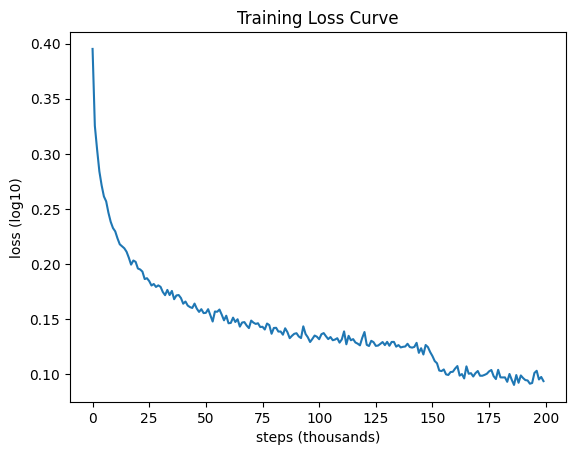

In [27]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.title('Training Loss Curve')
plt.xlabel('steps (thousands)')
plt.ylabel('loss (log10)')
plt.show()

# Final Takeaways:
The output is actually readable now. "Villa", "Newcastle", "Manchester", "Brentford", "Brighton" are coming through naturally. The model knows what a free kick is, what half time is, what a goalkeeper does. That is not something the MLP could do.

The reason is the hierarchical architecture. Instead of flattening everything at once, WaveNet combines characters in pairs progressively. It learns small patterns first, then builds bigger patterns on top of those. That extra depth makes a real difference.

Loss is 1.19 compared to 1.68 in batchnorm. The loss curve keeps going down all the way to 200k steps, never flattening out, so the model could honestly keep improving with more training.